# 02 — Feature Engineering Multi-valeurs

**Objectif** : Parser proprement les cellules multi-valeurs, créer des colonnes positionnelles `_1.._k`, et ajouter des features structurelles.

**Entrée** : `data/data.csv` (brut)  
**Sortie** : `data/data_raw.csv` (après feature engineering, avant nettoyage ML)

In [1]:
# ── Cellule optionnelle d'installation ────────────────────────────────────────
RUN_INSTALL = False
if RUN_INSTALL:
    import subprocess, sys
    pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "scipy"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

## 1. Imports & Chargement

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", palette="muted")

NOTEBOOK_DIR = Path().resolve()
DATA_DIR     = NOTEBOOK_DIR / "data"
DATA_FILE    = DATA_DIR / "data.csv"
OUT_FILE     = DATA_DIR / "data_raw.csv"

print(f"Lecture  : {DATA_FILE}")
print(f"Écriture : {OUT_FILE}")

Lecture  : C:\projet ingeneurie des réseaux\notebooks\data\data.csv
Écriture : C:\projet ingeneurie des réseaux\notebooks\data\data_raw.csv


In [3]:
df_raw = pd.read_csv(
    DATA_FILE,
    sep=";",
    dtype=str,
    na_values=["", "n/a", "N/A", "NA", "nan", "NaN", "null"],
    keep_default_na=True,
    encoding="utf-8",
    encoding_errors="replace",
)
df_raw.columns = df_raw.columns.str.strip()
df = df_raw.copy()
print(f"Shape initial : {df.shape}")
df.head(3)

Shape initial : (8332, 8)


,Time,Band (active),Channel number (active),Scrambling code (active),RSCP (active),Ec/N0 (active),RSCP (detected),Scrambling code (detected)
0,8:36:11.915,UMTS FDD 2100 band 1,10738,387,-73.2,-9.9,NaN,NaN
1,8:36:12.338,UMTS FDD 2100 band 1,10738,387,-78.1,-14.3,NaN,NaN
2,8:36:13.021,UMTS FDD 2100 band 1,10738,387,-74.3,-10.6,NaN,NaN


## 2. Renommage propre des colonnes

On normalise les noms pour éviter les espaces, parenthèses et caractères spéciaux.

In [4]:
# Mapping explicite — défensif : on ne renomme que les colonnes effectivement présentes
RENAME_MAP = {
    "Time"                       : "time",
    "Band (active)"               : "band",
    "Channel number (active)"     : "channel_raw",
    "Scrambling code (active)"    : "sc_active_raw",
    "RSCP (active)"               : "rscp_active_raw",
    "Ec/N0 (active)"              : "ecno_active_raw",
    "RSCP (detected)"             : "rscp_detected_raw",
    "Scrambling code (detected)"  : "sc_detected_raw",
}

# Appliquer uniquement les colonnes existantes
rename_effective = {k: v for k, v in RENAME_MAP.items() if k in df.columns}
df = df.rename(columns=rename_effective)

print("Colonnes renommées :")
for old, new in rename_effective.items():
    print(f"  '{old}' → '{new}'")
print(f"\nColonnes actuelles : {list(df.columns)}")

Colonnes renommées :
  'Time' → 'time'
  'Band (active)' → 'band'
  'Channel number (active)' → 'channel_raw'
  'Scrambling code (active)' → 'sc_active_raw'
  'RSCP (active)' → 'rscp_active_raw'
  'Ec/N0 (active)' → 'ecno_active_raw'
  'RSCP (detected)' → 'rscp_detected_raw'
  'Scrambling code (detected)' → 'sc_detected_raw'

Colonnes actuelles : ['time', 'band', 'channel_raw', 'sc_active_raw', 'rscp_active_raw', 'ecno_active_raw', 'rscp_detected_raw', 'sc_detected_raw']


## 3. Fonctions utilitaires de parsing multi-valeurs

In [5]:
def parse_multivalue_numeric(series: pd.Series, prefix: str, max_k: int = None) -> pd.DataFrame:
    """
    Prend une Series de chaînes (potentiellement multi-valeurs séparées par virgule),
    et retourne un DataFrame avec :
      - {prefix}_1, {prefix}_2, ... {prefix}_k  (valeurs positionnelles numériques)
      - {prefix}_n_vals                          (nombre de valeurs non-NaN par cellule)
      - {prefix}_present                         (booléen : au moins 1 valeur)
    """
    # Splitter chaque cellule sur la virgule
    split_series = series.apply(
        lambda x: [v.strip() for v in str(x).split(",")] if pd.notna(x) else []
    )

    # Déterminer le nombre max de sous-valeurs
    actual_max = split_series.apply(len).max()
    k = actual_max if max_k is None else min(max_k, actual_max)
    k = max(k, 1)  # au moins 1

    out = pd.DataFrame(index=series.index)

    for i in range(1, k + 1):
        col_name = f"{prefix}_{i}"
        out[col_name] = split_series.apply(
            lambda lst, idx=i-1: float(lst[idx]) if idx < len(lst) and lst[idx] not in ("", "n/a", "N/A", "nan", "NaN") else np.nan
        )

    # Feature structurelle : nb de valeurs présentes (non-NaN)
    value_cols = [f"{prefix}_{i}" for i in range(1, k + 1)]
    out[f"{prefix}_n_vals"] = out[value_cols].notna().sum(axis=1)
    out[f"{prefix}_present"] = (out[f"{prefix}_n_vals"] > 0).astype(int)

    return out


def parse_multivalue_int(series: pd.Series, prefix: str, max_k: int = None) -> pd.DataFrame:
    """
    Identique à parse_multivalue_numeric mais convertit en Int64 (entier nullable)
    pour les colonnes comme channel et scrambling code.
    """
    out = parse_multivalue_numeric(series, prefix, max_k)
    val_cols = [c for c in out.columns if c not in (f"{prefix}_n_vals", f"{prefix}_present")]
    for c in val_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").astype("Int64")
    return out

print("✅ Fonctions utilitaires définies")

✅ Fonctions utilitaires définies


## 4. Parsing des colonnes multi-valeurs

In [6]:
# ── 4.1 Channel number (actif) ────────────────────────────────────────────────
if "channel_raw" in df.columns:
    df_channel = parse_multivalue_int(df["channel_raw"], prefix="channel")
    print(f"channel → {list(df_channel.columns)}")
    print(df_channel.head(4))
else:
    df_channel = pd.DataFrame(index=df.index)
    print("⚠️  Colonne channel_raw absente — ignorée")

channel → ['channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_n_vals', 'channel_present']
   channel_1  channel_2  channel_3  channel_4  channel_5  channel_n_vals  \
0      10738       <NA>       <NA>       <NA>       <NA>               1   
1      10738       <NA>       <NA>       <NA>       <NA>               1   
2      10738       <NA>       <NA>       <NA>       <NA>               1   
3      10713      10738       <NA>       <NA>       <NA>               2   

   channel_present  
0                1  
1                1  
2                1  
3                1  


In [ ]:
# ── 4.2 Scrambling code (actif) ───────────────────────────────────────────────
if "sc_active_raw" in df.columns:
    df_sc_active = parse_multivalue_int(df["sc_active_raw"], prefix="sc_active")
    print(f"sc_active → {list(df_sc_active.columns)}")
    print(df_sc_active.head(4))
else:
    df_sc_active = pd.DataFrame(index=df.index)
    print("Colonne sc_active_raw absente — ignorée")

sc_active → ['sc_active_1', 'sc_active_2', 'sc_active_3', 'sc_active_4', 'sc_active_5', 'sc_active_n_vals', 'sc_active_present']
   sc_active_1  sc_active_2  sc_active_3  sc_active_4  sc_active_5  \
0          387         <NA>         <NA>         <NA>         <NA>   
1          387         <NA>         <NA>         <NA>         <NA>   
2          387         <NA>         <NA>         <NA>         <NA>   
3          387          387         <NA>         <NA>         <NA>   

   sc_active_n_vals  sc_active_present  
0                 1                  1  
1                 1                  1  
2                 1                  1  
3                 2                  1  


In [ ]:
# ── 4.3 RSCP actif (dBm) ─────────────────────────────────────────────────────
if "rscp_active_raw" in df.columns:
    df_rscp_active = parse_multivalue_numeric(df["rscp_active_raw"], prefix="rscp_active")
    print(f"rscp_active → {list(df_rscp_active.columns)}")
    print(df_rscp_active.head(4))
else:
    df_rscp_active = pd.DataFrame(index=df.index)
    print("Colonne rscp_active_raw absente — ignorée")

rscp_active → ['rscp_active_1', 'rscp_active_2', 'rscp_active_3', 'rscp_active_4', 'rscp_active_5', 'rscp_active_n_vals', 'rscp_active_present']
   rscp_active_1  rscp_active_2  rscp_active_3  rscp_active_4  rscp_active_5  \
0          -73.2            NaN            NaN            NaN            NaN   
1          -78.1            NaN            NaN            NaN            NaN   
2          -74.3            NaN            NaN            NaN            NaN   
3          -68.1          -71.9            NaN            NaN            NaN   

   rscp_active_n_vals  rscp_active_present  
0                   1                    1  
1                   1                    1  
2                   1                    1  
3                   2                    1  


In [9]:
# ── 4.4 Ec/N0 actif (dB) ─────────────────────────────────────────────────────
if "ecno_active_raw" in df.columns:
    df_ecno_active = parse_multivalue_numeric(df["ecno_active_raw"], prefix="ecno_active")
    print(f"ecno_active → {list(df_ecno_active.columns)}")
    print(df_ecno_active.head(4))
else:
    df_ecno_active = pd.DataFrame(index=df.index)
    print("  Colonne ecno_active_raw absente — ignorée")

ecno_active → ['ecno_active_1', 'ecno_active_2', 'ecno_active_3', 'ecno_active_4', 'ecno_active_5', 'ecno_active_n_vals', 'ecno_active_present']
   ecno_active_1  ecno_active_2  ecno_active_3  ecno_active_4  ecno_active_5  \
0           -9.9            NaN            NaN            NaN            NaN   
1          -14.3            NaN            NaN            NaN            NaN   
2          -10.6            NaN            NaN            NaN            NaN   
3           -7.0           -7.2            NaN            NaN            NaN   

   ecno_active_n_vals  ecno_active_present  
0                   1                    1  
1                   1                    1  
2                   1                    1  
3                   2                    1  


In [11]:
def parse_multivalue_numeric(series, prefix="val", sep="|"):
    """
    Transforme une Series de chaînes multivaleurs en colonnes numériques.
    Ex: "1|-95|-" -> val_1=1.0, val_2=-95.0, val_3=NaN
    """
    # Valeurs considérées comme manquantes
    MISSING = {"", "-", "--", "n/a", "N/A", "na", "NA", "nan", "NaN", "None", "null", "NULL"}

    def to_float(x):
        if x is None:
            return np.nan
        x = str(x).strip().replace(",", ".")
        if x in MISSING:
            return np.nan
        return pd.to_numeric(x, errors="coerce")

    # Split en listes
    split_series = (
        series.fillna("")
        .astype(str)
        .str.split(sep)
    )

    # Nombre max d'éléments
    k = split_series.map(len).max() if len(split_series) else 0

    # Construction du DataFrame de sortie
    out = pd.DataFrame(index=series.index)
    for i in range(1, k + 1):
        col_name = f"{prefix}_{i}"
        out[col_name] = split_series.apply(
            lambda lst, idx=i-1: to_float(lst[idx]) if idx < len(lst) else np.nan
        )

    return out

df_rscp_detected = parse_multivalue_numeric(df["rscp_detected_raw"], prefix="rscp_detected")


In [12]:
# ── 4.6 Scrambling code détecté ──────────────────────────────────────────────
if "sc_detected_raw" in df.columns:
    df_sc_detected = parse_multivalue_int(df["sc_detected_raw"], prefix="sc_detected")
    print(f"sc_detected → {list(df_sc_detected.columns)}")
    print(df_sc_detected.head(4))
else:
    df_sc_detected = pd.DataFrame(index=df.index)
    print("⚠️  Colonne sc_detected_raw absente — ignorée")

sc_detected → ['sc_detected_1', 'sc_detected_2', 'sc_detected_3', 'sc_detected_4', 'sc_detected_5', 'sc_detected_6', 'sc_detected_7', 'sc_detected_8', 'sc_detected_9', 'sc_detected_10', 'sc_detected_11', 'sc_detected_12', 'sc_detected_13', 'sc_detected_14', 'sc_detected_15', 'sc_detected_16', 'sc_detected_17', 'sc_detected_18', 'sc_detected_19', 'sc_detected_20', 'sc_detected_21', 'sc_detected_22', 'sc_detected_23', 'sc_detected_24', 'sc_detected_25', 'sc_detected_26', 'sc_detected_27', 'sc_detected_28', 'sc_detected_29', 'sc_detected_30', 'sc_detected_31', 'sc_detected_32', 'sc_detected_33', 'sc_detected_34', 'sc_detected_35', 'sc_detected_36', 'sc_detected_37', 'sc_detected_38', 'sc_detected_39', 'sc_detected_40', 'sc_detected_41']
   sc_detected_1  sc_detected_2  sc_detected_3  sc_detected_4  sc_detected_5  \
0           <NA>           <NA>           <NA>           <NA>           <NA>   
1           <NA>           <NA>           <NA>           <NA>           <NA>   
2           <NA>

## 5. Assemblage du DataFrame enrichi

In [13]:
# Colonnes de base à conserver
base_cols = [c for c in ["time", "band"] if c in df.columns]
df_base   = df[base_cols].copy()

# Concaténation horizontale de tous les blocs
df_eng = pd.concat(
    [df_base, df_channel, df_sc_active, df_rscp_active,
     df_ecno_active, df_rscp_detected, df_sc_detected],
    axis=1
)

print(f"Shape après feature engineering : {df_eng.shape}")
print(f"Nouvelles colonnes : {list(df_eng.columns)}")
df_eng.head(5)

Shape après feature engineering : (8332, 72)
Nouvelles colonnes : ['time', 'band', 'channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_n_vals', 'channel_present', 'sc_active_1', 'sc_active_2', 'sc_active_3', 'sc_active_4', 'sc_active_5', 'sc_active_n_vals', 'sc_active_present', 'rscp_active_1', 'rscp_active_2', 'rscp_active_3', 'rscp_active_4', 'rscp_active_5', 'rscp_active_n_vals', 'rscp_active_present', 'ecno_active_1', 'ecno_active_2', 'ecno_active_3', 'ecno_active_4', 'ecno_active_5', 'ecno_active_n_vals', 'ecno_active_present', 'rscp_detected_1', 'sc_detected_1', 'sc_detected_2', 'sc_detected_3', 'sc_detected_4', 'sc_detected_5', 'sc_detected_6', 'sc_detected_7', 'sc_detected_8', 'sc_detected_9', 'sc_detected_10', 'sc_detected_11', 'sc_detected_12', 'sc_detected_13', 'sc_detected_14', 'sc_detected_15', 'sc_detected_16', 'sc_detected_17', 'sc_detected_18', 'sc_detected_19', 'sc_detected_20', 'sc_detected_21', 'sc_detected_22', 'sc_detected_23', 'sc_detected_24

,time,band,channel_1,channel_2,channel_3,channel_4,channel_5,channel_n_vals,channel_present,sc_active_1,sc_active_2,sc_active_3,sc_active_4,sc_active_5,sc_active_n_vals,sc_active_present,rscp_active_1,rscp_active_2,rscp_active_3,rscp_active_4,rscp_active_5,rscp_active_n_vals,rscp_active_present,ecno_active_1,ecno_active_2,ecno_active_3,ecno_active_4,ecno_active_5,ecno_active_n_vals,ecno_active_present,rscp_detected_1,sc_detected_1,sc_detected_2,sc_detected_3,sc_detected_4,sc_detected_5,sc_detected_6,sc_detected_7,sc_detected_8,sc_detected_9,sc_detected_10,sc_detected_11,sc_detected_12,sc_detected_13,sc_detected_14,sc_detected_15,sc_detected_16,sc_detected_17,sc_detected_18,sc_detected_19,sc_detected_20,sc_detected_21,sc_detected_22,sc_detected_23,sc_detected_24,sc_detected_25,sc_detected_26,sc_detected_27,sc_detected_28,sc_detected_29,sc_detected_30,sc_detected_31,sc_detected_32,sc_detected_33,sc_detected_34,sc_detected_35,sc_detected_36,sc_detected_37,sc_detected_38,sc_detected_39,sc_detected_40,sc_detected_41
0,8:36:11.915,UMTS FDD 2100 band 1,10738,<NA>,<NA>,<NA>,<NA>,1,1,387,<NA>,<NA>,<NA>,<NA>,1,1,-73.2,NaN,NaN,NaN,NaN,1,1,-9.9,NaN,NaN,NaN,NaN,1,1,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,8:36:12.338,UMTS FDD 2100 band 1,10738,<NA>,<NA>,<NA>,<NA>,1,1,387,<NA>,<NA>,<NA>,<NA>,1,1,-78.1,NaN,NaN,NaN,NaN,1,1,-14.3,NaN,NaN,NaN,NaN,1,1,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,8:36:13.021,UMTS FDD 2100 band 1,10738,<NA>,<NA>,<NA>,<NA>,1,1,387,<NA>,<NA>,<NA>,<NA>,1,1,-74.3,NaN,NaN,NaN,NaN,1,1,-10.6,NaN,NaN,NaN,NaN,1,1,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,8:36:13.535,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1",10713,10738,<NA>,<NA>,<NA>,2,1,387,387,<NA>,<NA>,<NA>,2,1,-68.1,-71.9,NaN,NaN,NaN,2,1,-7.0,-7.2,NaN,NaN,NaN,2,1,NaN,395,138,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,8:36:14.018,"UMTS FDD 2100 band 1, UMTS FDD 2100 band 1",10738,10713,<NA>,<NA>,<NA>,2,1,387,387,<NA>,<NA>,<NA>,2,1,-71.4,-69.1,NaN,NaN,NaN,2,1,-5.9,-8.2,NaN,NaN,NaN,2,1,NaN,395,138,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## 6. Features dérivées supplémentaires

In [ ]:
# ── 6.1 Stats agrégées sur les RSCP actifs (sans supprimer les colonnes _1.._k)
rscp_act_cols = [c for c in df_eng.columns if c.startswith("rscp_active_") and c[-1].isdigit()]
if rscp_act_cols:
    df_eng["rscp_active_mean"] = df_eng[rscp_act_cols].mean(axis=1)
    df_eng["rscp_active_max"]  = df_eng[rscp_act_cols].max(axis=1)
    df_eng["rscp_active_min"]  = df_eng[rscp_act_cols].min(axis=1)
    df_eng["rscp_active_std"]  = df_eng[rscp_act_cols].std(axis=1)
    df_eng["rscp_active_range"]= df_eng["rscp_active_max"] - df_eng["rscp_active_min"]
    print(f" Features RSCP actif (mean/max/min/std/range) créées — {len(rscp_act_cols)} colonnes source")

# ── 6.2 Stats agrégées sur Ec/N0
ecno_cols = [c for c in df_eng.columns if c.startswith("ecno_active_") and c[-1].isdigit()]
if ecno_cols:
    df_eng["ecno_active_mean"] = df_eng[ecno_cols].mean(axis=1)
    df_eng["ecno_active_max"]  = df_eng[ecno_cols].max(axis=1)
    df_eng["ecno_active_min"]  = df_eng[ecno_cols].min(axis=1)
    df_eng["ecno_active_std"]  = df_eng[ecno_cols].std(axis=1)
    print(f" Features Ec/N0 (mean/max/min/std) créées — {len(ecno_cols)} colonnes source")

# ── 6.3 Stats sur RSCP détecté
rscp_det_cols = [c for c in df_eng.columns if c.startswith("rscp_detected_") and c[-1].isdigit()]
if rscp_det_cols:
    df_eng["rscp_detected_mean"] = df_eng[rscp_det_cols].mean(axis=1)
    df_eng["rscp_detected_max"]  = df_eng[rscp_det_cols].max(axis=1)
    df_eng["rscp_detected_min"]  = df_eng[rscp_det_cols].min(axis=1)
    print(f" Features RSCP détecté (mean/max/min) créées")

# ── 6.4 Diversité cellulaire : nb de cellules détectées vs actives
n_det_col = "rscp_detected_n_vals"
n_act_col = "rscp_active_n_vals"
if n_det_col in df_eng.columns and n_act_col in df_eng.columns:
    df_eng["n_cells_ratio"] = (
        df_eng[n_det_col] / df_eng[n_act_col].replace(0, np.nan)
    ).fillna(0)
    print(" Feature n_cells_ratio créée")

# ── 6.5 Différence RSCP actif vs meilleur détecté
if "rscp_active_1" in df_eng.columns and "rscp_detected_max" in df_eng.columns:
    df_eng["rscp_delta_active_vs_best_detected"] = (
        df_eng["rscp_active_1"] - df_eng["rscp_detected_max"]
    )
    print(" Feature rscp_delta_active_vs_best_detected créée")

print(f"\nShape final : {df_eng.shape}")

✅ Features RSCP actif (mean/max/min/std/range) créées — 5 colonnes source
✅ Features Ec/N0 (mean/max/min/std) créées — 5 colonnes source
✅ Features RSCP détecté (mean/max/min) créées
✅ Feature rscp_delta_active_vs_best_detected créée

Shape final : (8332, 85)


## 7. Visualisations rapides post-feature engineering

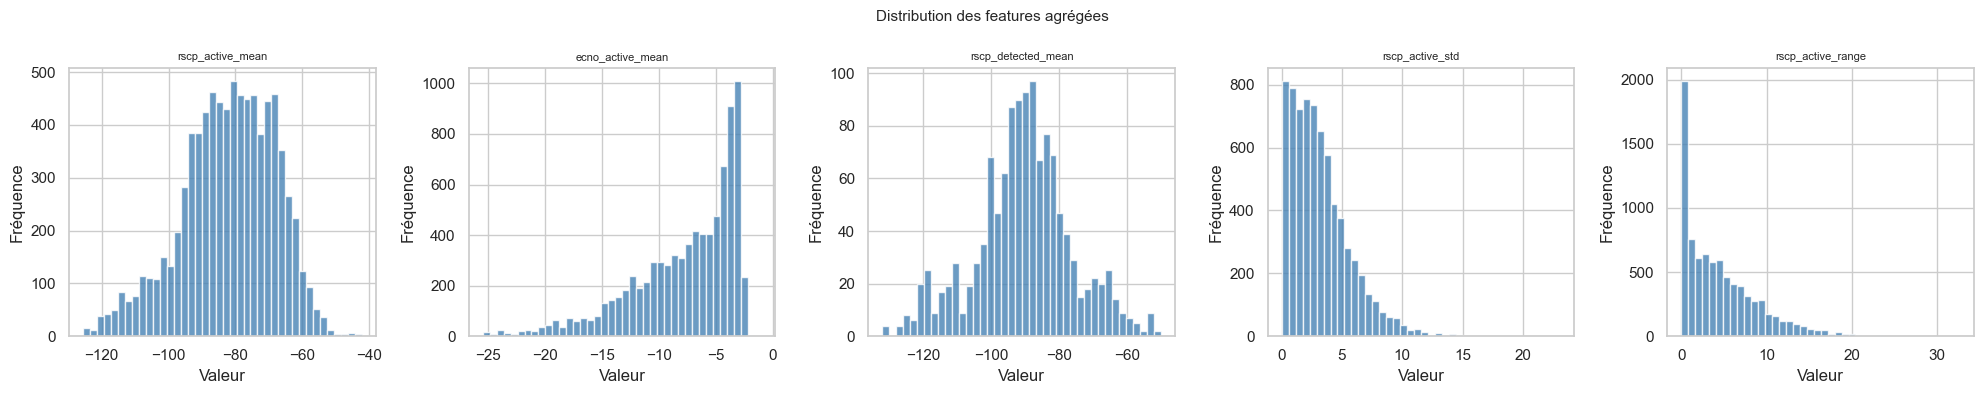

In [15]:
# Distribution des features numériques agrégées
agg_features = [
    c for c in ["rscp_active_mean", "ecno_active_mean", "rscp_detected_mean",
                "rscp_active_std", "rscp_active_range"]
    if c in df_eng.columns
]

if agg_features:
    fig, axes = plt.subplots(1, len(agg_features), figsize=(4 * len(agg_features), 4))
    if len(agg_features) == 1:
        axes = [axes]
    for ax, feat in zip(axes, agg_features):
        data = df_eng[feat].dropna()
        ax.hist(data, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
        ax.set_title(feat, fontsize=8)
        ax.set_xlabel("Valeur")
        ax.set_ylabel("Fréquence")
    plt.suptitle("Distribution des features agrégées", fontsize=11)
    plt.tight_layout()
    plt.show()

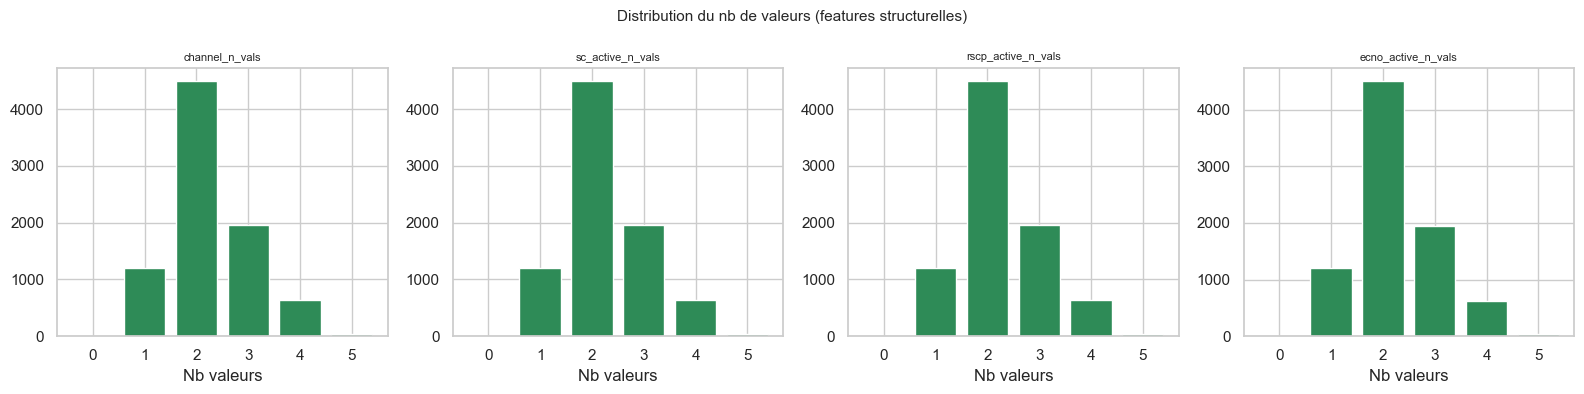

In [16]:
# Distribution du nombre de valeurs par observation
n_val_cols = [c for c in df_eng.columns if c.endswith("_n_vals")]
if n_val_cols:
    fig, axes = plt.subplots(1, len(n_val_cols), figsize=(4 * len(n_val_cols), 4))
    if len(n_val_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, n_val_cols):
        vc = df_eng[col].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color="seagreen", edgecolor="white")
        ax.set_title(col, fontsize=8)
        ax.set_xlabel("Nb valeurs")
    plt.suptitle("Distribution du nb de valeurs (features structurelles)", fontsize=11)
    plt.tight_layout()
    plt.show()

## 8. Sauvegarde

In [17]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
df_eng.to_csv(OUT_FILE, index=False, encoding="utf-8")
print(f" Sauvegardé : {OUT_FILE}")
print(f"   Shape : {df_eng.shape}")
print(f"   Colonnes : {list(df_eng.columns)}")

 Sauvegardé : C:\projet ingeneurie des réseaux\notebooks\data\data_raw.csv
   Shape : (8332, 85)
   Colonnes : ['time', 'band', 'channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_n_vals', 'channel_present', 'sc_active_1', 'sc_active_2', 'sc_active_3', 'sc_active_4', 'sc_active_5', 'sc_active_n_vals', 'sc_active_present', 'rscp_active_1', 'rscp_active_2', 'rscp_active_3', 'rscp_active_4', 'rscp_active_5', 'rscp_active_n_vals', 'rscp_active_present', 'ecno_active_1', 'ecno_active_2', 'ecno_active_3', 'ecno_active_4', 'ecno_active_5', 'ecno_active_n_vals', 'ecno_active_present', 'rscp_detected_1', 'sc_detected_1', 'sc_detected_2', 'sc_detected_3', 'sc_detected_4', 'sc_detected_5', 'sc_detected_6', 'sc_detected_7', 'sc_detected_8', 'sc_detected_9', 'sc_detected_10', 'sc_detected_11', 'sc_detected_12', 'sc_detected_13', 'sc_detected_14', 'sc_detected_15', 'sc_detected_16', 'sc_detected_17', 'sc_detected_18', 'sc_detected_19', 'sc_detected_20', 'sc_detected_21', 'sc_de

## 9. Checks de validation

In [18]:
# Recharger pour valider
df_check = pd.read_csv(OUT_FILE)

assert df_check.shape[0] == df_eng.shape[0], "❌ Nombre de lignes incohérent"
assert df_check.shape[1] == df_eng.shape[1], "❌ Nombre de colonnes incohérent"
assert OUT_FILE.exists(), "❌ Fichier de sortie introuvable"

# Vérification colonnes positionnelles
for prefix in ["channel", "sc_active", "rscp_active", "ecno_active"]:
    col_1 = f"{prefix}_1"
    assert col_1 in df_check.columns or f"{prefix}_raw" not in df_raw.columns, \
        f"❌ Colonne {col_1} manquante"

# Vérification features structurelles
n_val_cols_check = [c for c in df_check.columns if c.endswith("_n_vals")]
assert len(n_val_cols_check) > 0, "❌ Aucune feature _n_vals trouvée"

print(f"✅ Toutes assertions passées")
print(f"   {df_check.shape[0]:,} lignes × {df_check.shape[1]} colonnes")
print(f"   Features structurelles : {n_val_cols_check}")
print("\n📌 Prochaine étape : 03_nettoyage_preprocessing.ipynb")

✅ Toutes assertions passées
   8,332 lignes × 85 colonnes
   Features structurelles : ['channel_n_vals', 'sc_active_n_vals', 'rscp_active_n_vals', 'ecno_active_n_vals']

📌 Prochaine étape : 03_nettoyage_preprocessing.ipynb
